# アドバンスドコンペ用データセット（DBBench）素性の分析
## 分析対象
1. ALFWorld：家庭内タスク
- u-10bei/sft_alfworld_trajectory_dataset
- u-10bei/sft_alfworld_trajectory_dataset_v2
- u-10bei/sft_alfworld_trajectory_dataset_v3
- u-10bei/sft_alfworld_trajectory_dataset_v4
- u-10bei/sft_alfworld_trajectory_dataset_v5

2. DBBench：データベース操作  ★こっち
- u-10bei/dbbench_sft_dataset_react
- u-10bei/dbbench_sft_dataset_react_v2
- u-10bei/dbbench_sft_dataset_react_v3
- u-10bei/dbbench_sft_dataset_react_v4


## HuggingFaceログイン

In [ ]:
import os
import pandas as pd
from google.colab import userdata


# HF_TOKENを環境変数またはColabの秘密鍵から取得
# Colabの左側のパネルにある「秘密鍵（🔑）」アイコンをクリックし、
# 「HF_TOKEN」という名前でトークンを設定してください。
HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    HF_TOKEN = userdata.get('HF_TOKEN') # 秘密鍵サービスに登録した名前に変更

if not HF_TOKEN:
    print("警告: HF_TOKENが見つかりません。Hugging Faceへのログインが失敗する可能性があります。")

from huggingface_hub import login
login(token=HF_TOKEN, add_to_git_credential=True)

## 事前準備

In [ ]:
from datasets import load_dataset, Dataset
import json
from huggingface_hub import hf_hub_download

In [ ]:
def safe_load_dataset(dataset_id, hf_token):
    try:
        # First, try standard loading
        ds_all = load_dataset(dataset_id, split="train", token=hf_token)
    except Exception as e:
        print(f"[WARN] Standard load failed: {e}\nTrying manual loading (download -> parse -> normalize keys)...")
        try:
            # 手動ダウンロード
            # Note: ファイル名はデータセットによって異なります。必要に応じて変更してください。
            # ファイル名はデータセットに応じて変更してください
            file_path = hf_hub_download(repo_id=dataset_id, filename="data.jsonl", repo_type="dataset", token=hf_token)

            with open(file_path, "r", encoding="utf-8") as f:
                lines = f.readlines()

            data_list = []
            for line in lines:
                if line.strip():
                    data_list.append(json.loads(line))

            if not data_list:
                raise ValueError("Downloaded file is empty.")

            # キーを正規化: すべての辞書に見つかったキーの和集合が含まれるようにします
            all_keys = set().union(*(d.keys() for d in data_list))
            for d in data_list:
                for k in all_keys:
                    if k not in d:
                        d[k] = None

            ds_all = Dataset.from_list(data_list)
            print(f"[INFO] Manual load successful. {len(ds_all)} rows loaded.")

        except Exception as e2:
            print(f"[ERROR] Manual load also failed: {e2}")
            raise e  # フォールバックが失敗した場合は元のエラーを発生させる

    print(f"[INFO] Loaded dataset columns: {ds_all.column_names}")

    return ds_all

## DBBench標準データセット分析

In [ ]:
# 全てのデータセットを辞書形式で保持

dataset_ids =["u-10bei/dbbench_sft_dataset_react", "u-10bei/dbbench_sft_dataset_react_v2",
              "u-10bei/dbbench_sft_dataset_react_v3", "u-10bei/dbbench_sft_dataset_react_v4"]

dict_ds = {}
for dataset_id in dataset_ids:
    dict_ds[dataset_id] = safe_load_dataset(dataset_id, HF_TOKEN)
    print(f"[INFO] Loaded dataset: {dataset_id}")
    print(f"[INFO] Length of dataset: {len(dict_ds[dataset_id])}")
    print(f"[INFO] Sample data: {dict_ds[dataset_id][0]}")

[INFO] Loaded dataset columns: ['id', 'messages', 'metadata']
[INFO] Loaded dataset: u-10bei/dbbench_sft_dataset_react
[INFO] Length of dataset: 300
[INFO] Sample data: {'id': 'dbbench_sft_0000', 'messages': [{'role': 'user', 'content': '\nI will ask you a question, then you should help me operate a MySQL database with SQL to answer the question.\nYou have to explain the problem and your solution to me and write down your thoughts.\nAfter thinking and explaining thoroughly, every round you can choose to operate or to answer.\nyour operation should be like this:\nAction: Operation\n```sql\nSELECT * FROM table WHERE condition;\n```\nYou MUST put SQL in markdown format without any other comments. Your SQL should be in one line.\nEvery time you can only execute one SQL statement. I will only execute the statement in the first SQL code block. Every time you write a SQL, I will execute it for you and give you the output.\nIf you are done operating, and you want to commit your final answer, t

### v4でデータ形式の確認

In [ ]:
dict_ds["u-10bei/dbbench_sft_dataset_react_v4"]

Dataset({
    features: ['id', 'messages', 'metadata'],
    num_rows: 1200
})

In [ ]:
for key in dict_ds["u-10bei/dbbench_sft_dataset_react_v4"].column_names:
    print(key)
    print(dict_ds["u-10bei/dbbench_sft_dataset_react_v4"][key])

id
Column(['dbbench_sft_0000', 'dbbench_sft_0001', 'dbbench_sft_0002', 'dbbench_sft_0003', 'dbbench_sft_0004'])
messages
Column([[{'role': 'user', 'content': '\nI will ask you a question, then you should help me operate a MySQL database with SQL to answer the question.\nYou have to explain the problem and your solution to me and write down your thoughts.\nAfter thinking and explaining thoroughly, every round you can choose to operate or to answer.\nyour operation should be like this:\nAction: Operation\n```sql\nSELECT * FROM table WHERE condition;\n```\nYou MUST put SQL in markdown format without any other comments. Your SQL should be in one line.\nEvery time you can only execute one SQL statement. I will only execute the statement in the first SQL code block. Every time you write a SQL, I will execute it for you and give you the output.\nIf you are done operating, and you want to commit your final answer, then write down:\nAction: Answer\nFinal Answer: ["ANSWER1", "ANSWER2", ...]\nDO 

In [ ]:
print(dict_ds["u-10bei/dbbench_sft_dataset_react_v4"]["metadata"][0])

{'type': 'aggregation-AVG',
 'table_name': 'Satellite Communications Data',
 'sql': "SELECT AVG(`Uplink (MHz)`) FROM `Satellite Communications Data` WHERE `Status` = 'Standby';",
 'label': ['6246.9'],
 'wrong_sql': None,
 'wrong_val': None,
 'correct_val': None,
 'where_col': None,
 'error_col': None,
 'error_reason': None}

In [ ]:
dict_ds["u-10bei/dbbench_sft_dataset_react_v4"]["messages"][0]

[{'role': 'user',
  'content': '\nI will ask you a question, then you should help me operate a MySQL database with SQL to answer the question.\nYou have to explain the problem and your solution to me and write down your thoughts.\nAfter thinking and explaining thoroughly, every round you can choose to operate or to answer.\nyour operation should be like this:\nAction: Operation\n```sql\nSELECT * FROM table WHERE condition;\n```\nYou MUST put SQL in markdown format without any other comments. Your SQL should be in one line.\nEvery time you can only execute one SQL statement. I will only execute the statement in the first SQL code block. Every time you write a SQL, I will execute it for you and give you the output.\nIf you are done operating, and you want to commit your final answer, then write down:\nAction: Answer\nFinal Answer: ["ANSWER1", "ANSWER2", ...]\nDO NOT write this pattern unless you are sure about your answer. I expect an accurate and correct answer.\nYour answer should be a

### データフレーム化

In [ ]:
def convert_to_dataframe(dataset):
    '''metadta, messagesをDataFrame形式で読み込んで結合'''

    meta_data = pd.DataFrame(dataset["metadata"])
    messages = pd.DataFrame(dataset["messages"])
    messages.columns = ['turn_'+ str(col) for col in messages.columns]
    merged_df = pd.concat([pd.DataFrame(meta_data), messages], axis=1)

    return merged_df

df_all = []
for ds_name in dict_ds.keys():
    print(ds_name)
    df_one = convert_to_dataframe(dict_ds[ds_name])
    df_one['dataset_name'] = ds_name
    df_all.append(df_one)

df_all = pd.concat(df_all, ignore_index=True).reset_index(drop=True)
# dataset_nameカラムを先頭に持ってくる
cols = df_all.columns.tolist()
cols = [cols[-1]] + cols[:-1]

# turn_1～turn9のカラムが最後尾に並ぶように変更する
not_turn_cols = [col for col in cols if not col.startswith('turn_')]
turn_cols = [col for col in cols if col.startswith('turn_')]
df_all = df_all[not_turn_cols+turn_cols]

df_all

u-10bei/dbbench_sft_dataset_react
u-10bei/dbbench_sft_dataset_react_v2
u-10bei/dbbench_sft_dataset_react_v3
u-10bei/dbbench_sft_dataset_react_v4


,type,table_name,sql,label,dataset_name,wrong_sql,error_col,error_reason,wrong_val,correct_val,...,turn_9,turn_0,turn_1,turn_2,turn_3,turn_4,turn_5,turn_6,turn_7,turn_8
0,comparison,American Higher Education Institutions,SELECT `Country` FROM `American Higher Educati...,[none],u-10bei/dbbench_sft_dataset_react,NaN,NaN,NaN,NaN,NaN,...,NaN,"{'role': 'user', 'content': ' I will ask you a...","{'role': 'assistant', 'content': 'Ok.'}","{'role': 'user', 'content': 'Which Country has...","{'role': 'assistant', 'content': 'I need to fi...","{'role': 'user', 'content': '[('none',)]'}","{'role': 'assistant', 'content': 'The query re...",NaN,NaN,NaN
1,INSERT,Silver Screen Episode Guide,INSERT INTO `Silver Screen Episode Guide` (`Ep...,[done],u-10bei/dbbench_sft_dataset_react,NaN,NaN,NaN,NaN,NaN,...,NaN,"{'role': 'user', 'content': ' I will ask you a...","{'role': 'assistant', 'content': 'Ok.'}","{'role': 'user', 'content': 'Insert a new reco...","{'role': 'assistant', 'content': 'I need to ad...","{'role': 'user', 'content': 'Query OK, 1 row a...","{'role': 'assistant', 'content': 'The query wa...",NaN,NaN,NaN
2,ranking,Conference League 2005 Season Standings,SELECT `Team` FROM `Conference League 2005 Sea...,[Springfield],u-10bei/dbbench_sft_dataset_react,NaN,NaN,NaN,NaN,NaN,...,NaN,"{'role': 'user', 'content': ' I will ask you a...","{'role': 'assistant', 'content': 'Ok.'}","{'role': 'user', 'content': 'Which Team has th...","{'role': 'assistant', 'content': 'This is a ra...","{'role': 'user', 'content': '[('Springfield',)]'}","{'role': 'assistant', 'content': 'The SQL quer...",NaN,NaN,NaN
3,INSERT,2010 Bestselling Books,"INSERT INTO `2010 Bestselling Books` (`Rank`, ...",[done],u-10bei/dbbench_sft_dataset_react,NaN,NaN,NaN,NaN,NaN,...,NaN,"{'role': 'user', 'content': ' I will ask you a...","{'role': 'assistant', 'content': 'Ok.'}","{'role': 'user', 'content': 'Insert a new reco...","{'role': 'assistant', 'content': 'I need to ad...","{'role': 'user', 'content': 'Query OK, 1 row a...","{'role': 'assistant', 'content': 'The query wa...",NaN,NaN,NaN
4,UPDATE,The Crown Affair Episode Guide,UPDATE `The Crown Affair Episode Guide` SET `E...,[done],u-10bei/dbbench_sft_dataset_react,NaN,NaN,NaN,NaN,NaN,...,NaN,"{'role': 'user', 'content': ' I will ask you a...","{'role': 'assistant', 'content': 'Ok.'}","{'role': 'user', 'content': 'Update the record...","{'role': 'assistant', 'content': 'I need to mo...","{'role': 'user', 'content': 'Query OK, 1 row a...","{'role': 'assistant', 'content': 'The operatio...",NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3055,INSERT,FDA_Approved_Medications,INSERT INTO `FDA_Approved_Medications` (`Name`...,[done],u-10bei/dbbench_sft_dataset_react_v4,None,None,None,None,None,...,None,"{'role': 'user', 'content': ' I will ask you a...","{'role': 'assistant', 'content': 'Ok.'}","{'role': 'user', 'content': 'Insert a new reco...","{'role': 'assistant', 'content': 'Since the sc...","{'role': 'user', 'content': 'Query OK, 1 row a...","{'role': 'assistant', 'content': 'The query wa...",None,None,None
3056,INSERT,Indianapolis 500 History,INSERT INTO `Indianapolis 500 History` (`Year`...,[done],u-10bei/dbbench_sft_dataset_react_v4,None,None,None,None,None,...,None,"{'role': 'user', 'content': ' I will ask you a...","{'role': 'assistant', 'content': 'Ok.'}","{'role': 'user', 'content': 'Insert a new reco...","{'role': 'assistant', 'content': 'Since the sc...","{'role': 'user', 'content': 'Query OK, 1 row a...","{'role': 'assistant', 'content': 'The operatio...",None,None,None
3057,comparison_error_recovery,Fox Programming,SELECT `Type` FROM `Fox Programming` WHERE `Du...,"[Drama, Reality, Drama]",u-10bei/dbbench_sft_dataset_react_v4,SELECT Type FROM `Fox Programming` WHERE `Dura...,Type,reserved,None,None,...,None,"{'role': 'user', 'content': ' I will ask you a...","{'role': 'assistant', 'content': 'Ok.'}","{'role': 'user', 'content': 'Which Type has Du...","{'role': 'a

### 分析

In [ ]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3060 entries, 0 to 3059
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   type          3060 non-null   object
 1   table_name    3060 non-null   object
 2   sql           3060 non-null   object
 3   label         3060 non-null   object
 4   dataset_name  3060 non-null   object
 5   wrong_sql     660 non-null    object
 6   error_col     560 non-null    object
 7   error_reason  500 non-null    object
 8   wrong_val     100 non-null    object
 9   correct_val   100 non-null    object
 10  where_col     100 non-null    object
 11  turn_9        100 non-null    object
 12  turn_0        3060 non-null   object
 13  turn_1        3060 non-null   object
 14  turn_2        3060 non-null   object
 15  turn_3        3060 non-null   object
 16  turn_4        3060 non-null   object
 17  turn_5        3060 non-null   object
 18  turn_6        660 non-null    object
 19  turn_7

In [ ]:
# バージョン毎に各カラムのサンプル数を確認
df_all.groupby('dataset_name').count()

,type,table_name,sql,label,wrong_sql,error_col,error_reason,wrong_val,correct_val,where_col,turn_9,turn_0,turn_1,turn_2,turn_3,turn_4,turn_5,turn_6,turn_7,turn_8
dataset_name,,,,,,,,,,,,,,,,,,,,
u-10bei/dbbench_sft_dataset_react,300,300,300,300,0,0,0,0,0,0,0,300,300,300,300,300,300,0,0,0
u-10bei/dbbench_sft_dataset_react_v2,360,360,360,360,60,60,0,0,0,0,0,360,360,360,360,360,360,60,60,0
u-10bei/dbbench_sft_dataset_react_v3,1200,1200,1200,1200,300,300,300,0,0,0,0,1200,1200,1200,1200,1200,1200,300,300,0
u-10bei/dbbench_sft_dataset_react_v4,1200,1200,1200,1200,300,200,200,100,100,100,100,1200,1200,1200,1200,1200,1200,300,300,100


#### バージョン毎のType別レコード数の分布

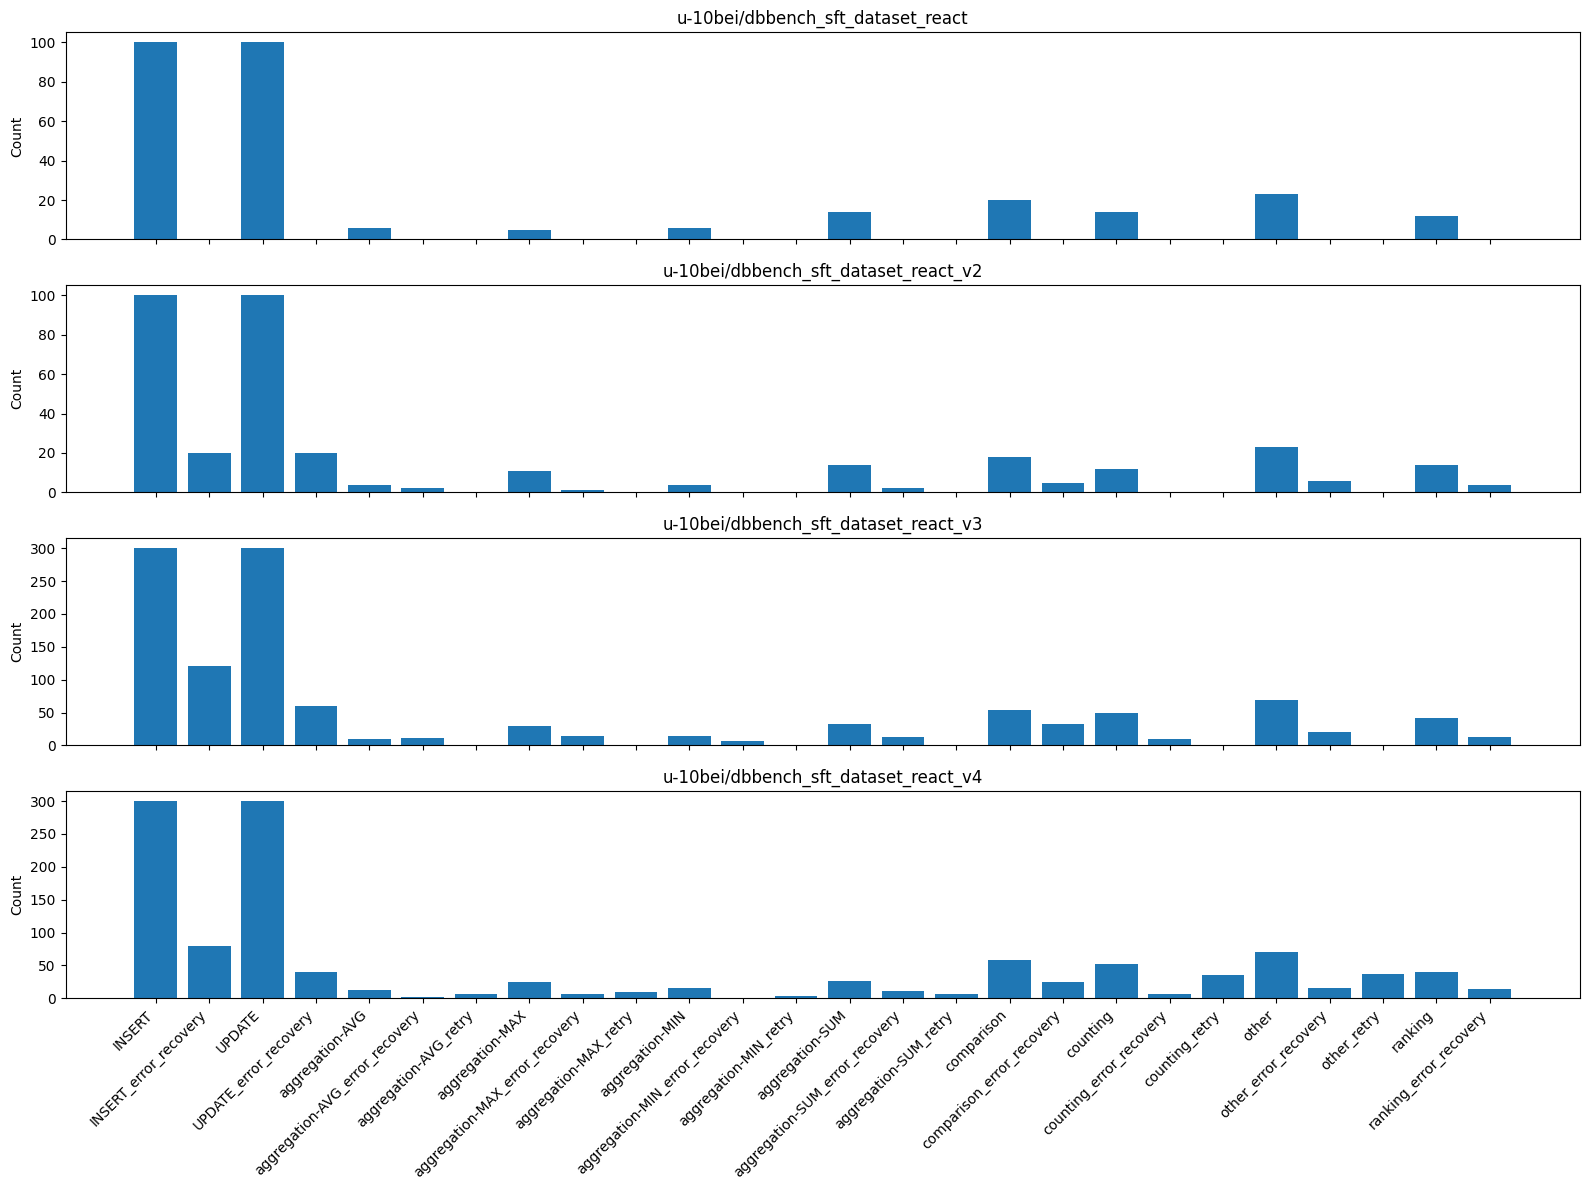

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. dataset_name × type の件数を集計
type_counts = (
    df_all
    .groupby(["dataset_name", "type"])
    .size()
    .reset_index(name="count")
)

# 2. 全バージョン共通の type 一覧（ソート済み）
all_types = sorted(type_counts["type"].unique())

# 3. データセット名（バージョン）の一覧（ソート）
datasets = sorted(type_counts["dataset_name"].unique())

# 4. 4×1 の棒グラフ
fig, axes = plt.subplots(len(datasets), 1, figsize=(16, 12), sharex=True)

# datasets が1つだけの時に備えてリスト化
if len(datasets) == 1:
    axes = [axes]

x = np.arange(len(all_types))

for ax, ds in zip(axes, datasets):
    # その dataset のみ抽出
    df_ds = type_counts[type_counts["dataset_name"] == ds]

    # 共通 type の順番に count を並べる（存在しない type は 0）
    counts = []
    for t in all_types:
        row = df_ds[df_ds["type"] == t]["count"]
        if len(row) == 0:
            counts.append(0)
        else:
            counts.append(row.values[0])

    ax.bar(x, counts)
    ax.set_title(ds)
    ax.set_ylabel("Count")

# 一番下のサブプロットだけ x 軸ラベルを表示
axes[-1].set_xticks(x)
axes[-1].set_xticklabels(all_types, rotation=45, ha="right")

plt.tight_layout()
plt.show()

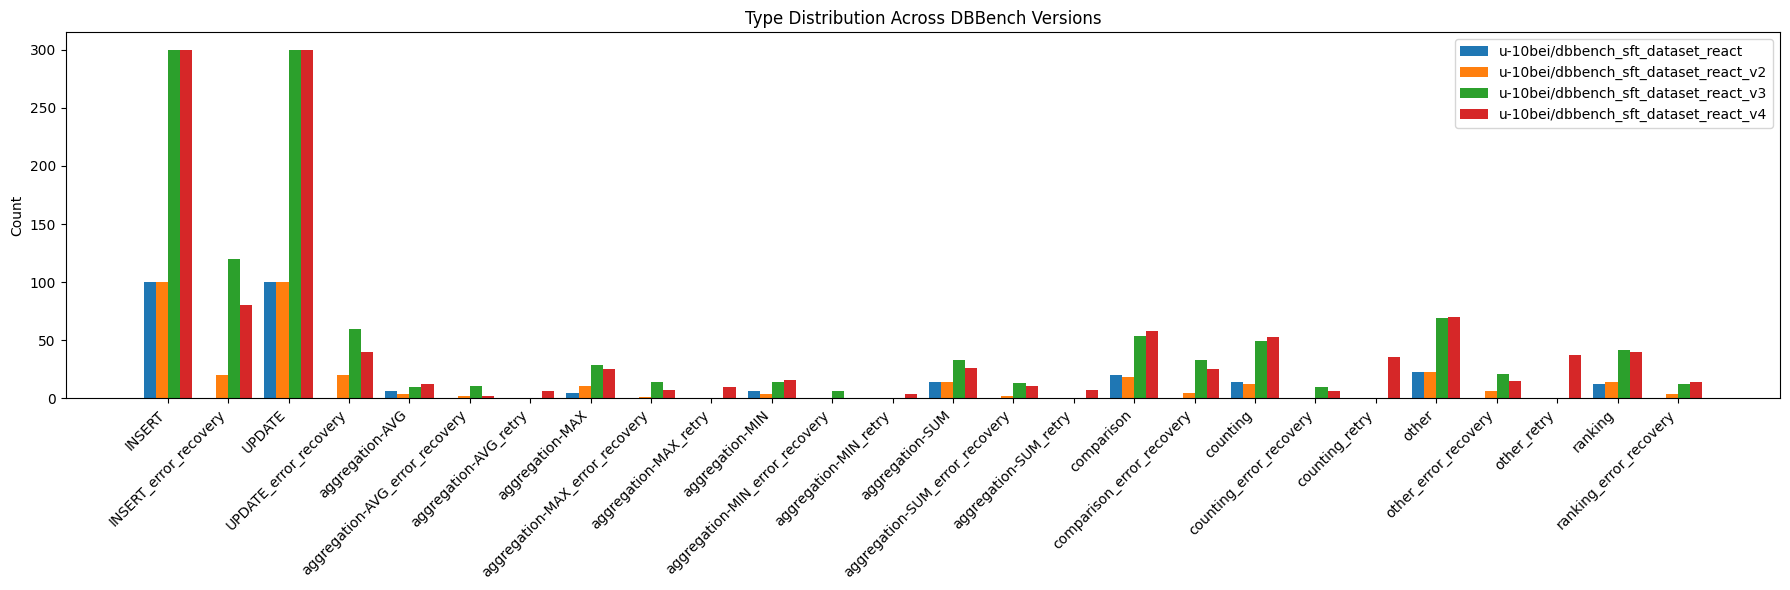

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1. dataset_name × type の件数を集計
# -----------------------------
type_counts = (
    df_all
    .groupby(["dataset_name", "type"])
    .size()
    .reset_index(name="count")
)

# -----------------------------
# 2. 共通 type 一覧（ソート）
# -----------------------------
all_types = sorted(type_counts["type"].unique())

# -----------------------------
# 3. dataset 一覧（ソート）
# -----------------------------
datasets = sorted(type_counts["dataset_name"].unique())

# -----------------------------
# 4. 可視化用マトリクス作成
# -----------------------------
data_matrix = []

for ds in datasets:
    df_ds = type_counts[type_counts["dataset_name"] == ds]
    counts = []
    for t in all_types:
        row = df_ds[df_ds["type"] == t]["count"]
        counts.append(row.values[0] if len(row) > 0 else 0)
    data_matrix.append(counts)

data_matrix = np.array(data_matrix)  # shape: (num_datasets, num_types)

# -----------------------------
# 5. グループ化棒グラフ描画
# -----------------------------
x = np.arange(len(all_types))
bar_width = 0.8 / len(datasets)

plt.figure(figsize=(18, 6))

for i, ds in enumerate(datasets):
    plt.bar(
        x + i * bar_width,
        data_matrix[i],
        width=bar_width,
        label=ds
    )

plt.xticks(x + bar_width * (len(datasets)-1)/2, all_types, rotation=45, ha="right")
plt.ylabel("Count")
plt.title("Type Distribution Across DBBench Versions")
plt.legend()
plt.tight_layout()
plt.show()